<div
  style="
    background-color: #f0f0f0;
    color:rgb(56, 56, 56);
    padding: 8px;
    display: flex;
    align-items: center;
    gap: 100px;
  "
>
  <img src="../../../images/brand.svg" style="max-height: 80px;">
  <strong>
    AI Saga: Data Science and Machine Learning</br>
    2.lab.1. Wisconsin Cancer Classification
  </strong>
</div>

### Background

You will continue working with the Wisconsin Diagnostic Cancer Dataset, but this time implementing classification models using scikit-learn.

The dataset includes:
- 569 instances
- 30 numeric features computed from the cell nuclei present in the image
- Binary classification: **Malignant** or **Benign** diagnosis

### Description

Your task is to implement logistic regression using scikit-learn to:

- Implement logistic regression using all features
- Find the best performing pair of features for classification
- Compare the accuracy between using all features vs. the best pair
- Visualize the decision boundary for the best feature pair

### Deliverables

- A **ipynb** (Jupyter Notebook) file called **wisconsin-cancer-classification.ipynb**
- The notebook should include visualizations of the decision boundaries
- A clear comparison of performance between using all features vs. the best pair
- Use the provided template as a starting point

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from itertools import combinations

# 1. Load and Explore the Dataset

In [2]:
raw_data = load_breast_cancer(as_frame=True)
df = raw_data.data
df['target'] = raw_data.target
df['diagnosis'] = df['target'].map({0: 'Malignant', 1: 'Benign'})

print(f'Dataset shape: {df.shape}')
print(f'\nTarget distribution:')
print(df['diagnosis'].value_counts())
print(f'\nFeature names ({len(raw_data.feature_names)}):')
print(raw_data.feature_names)
df.head()

Dataset shape: (569, 32)

Target distribution:
diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64

Feature names (30):
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,Malignant


# 2. Logistic Regression with All Features

In [3]:
X_all = df[raw_data.feature_names].values
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_all = LogisticRegression(max_iter=10000, random_state=42)
lr_all.fit(X_train_scaled, y_train)

y_pred_all = lr_all.predict(X_test_scaled)
accuracy_all = accuracy_score(y_test, y_pred_all)

print(f'Logistic Regression with ALL {X_all.shape[1]} features')
print(f'Accuracy: {accuracy_all:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_all, target_names=['Malignant', 'Benign']))

Logistic Regression with ALL 30 features
Accuracy: 0.9737

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.98      0.95      0.96        43
      Benign       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



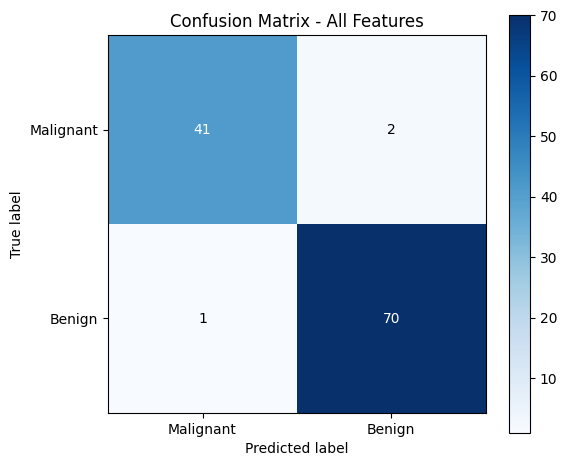

In [4]:
cm_all = confusion_matrix(y_test, y_pred_all)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_all, interpolation='nearest', cmap=plt.cm.Blues)
ax.set(xticks=[0, 1], yticks=[0, 1],
       xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'],
       title='Confusion Matrix - All Features',
       ylabel='True label', xlabel='Predicted label')
plt.colorbar(im)

for i in range(2):
    for j in range(2):
        ax.text(j, i, format(cm_all[i, j], 'd'), ha='center', va='center',
                color='white' if cm_all[i, j] > cm_all.max()/2 else 'black')

plt.tight_layout()
plt.savefig('data/confusion_matrix_all_features.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. Find the Best Pair of Features

In [5]:
feature_pairs = list(combinations(range(X_all.shape[1]), 2))
print(f'Total pairs to evaluate: {len(feature_pairs)}')

results = []

for i, j in feature_pairs:
    X_pair = X_all[:, [i, j]]
    X_tr, X_te, y_tr, y_te = train_test_split(X_pair, y, test_size=0.2, random_state=42)
    
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s = sc.transform(X_te)
    
    lr = LogisticRegression(max_iter=10000, random_state=42)
    lr.fit(X_tr_s, y_tr)
    y_pr = lr.predict(X_te_s)
    acc = accuracy_score(y_te, y_pr)
    
    results.append({
        'Feature 1': raw_data.feature_names[i],
        'Feature 2': raw_data.feature_names[j],
        'Accuracy': acc
    })

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print('\nTop 10 feature pairs:')
print(results_df.head(10).to_string(index=False))

Total pairs to evaluate: 435



Top 10 feature pairs:
      Feature 1               Feature 2  Accuracy
worst perimeter        worst smoothness  0.982456
   worst radius worst fractal dimension  0.982456
     worst area       worst compactness  0.973684
worst perimeter       worst compactness  0.973684
   worst radius        worst smoothness  0.973684
worst perimeter         worst concavity  0.973684
     worst area        worst smoothness  0.973684
   worst radius       worst compactness  0.973684
worst perimeter worst fractal dimension  0.973684
mean smoothness         worst perimeter  0.973684


In [6]:
best = results_df.iloc[0]
best_f1 = best['Feature 1']
best_f2 = best['Feature 2']
best_idx = [list(raw_data.feature_names).index(best_f1), list(raw_data.feature_names).index(best_f2)]

print(f'Best pair: {best_f1} + {best_f2}')
print(f'Accuracy: {best["Accuracy"]:.4f}')

Best pair: worst perimeter + worst smoothness
Accuracy: 0.9825


# 4. Train Model with Best Pair

In [7]:
X_best = X_all[:, best_idx]
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_best, y, test_size=0.2, random_state=42)

scaler_b = StandardScaler()
X_train_b_scaled = scaler_b.fit_transform(X_train_b)
X_test_b_scaled = scaler_b.transform(X_test_b)

lr_best = LogisticRegression(max_iter=10000, random_state=42)
lr_best.fit(X_train_b_scaled, y_train_b)

y_pred_best = lr_best.predict(X_test_b_scaled)
accuracy_best = accuracy_score(y_test_b, y_pred_best)

print(f'Logistic Regression with BEST PAIR: {best_f1} + {best_f2}')
print(f'Accuracy: {accuracy_best:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test_b, y_pred_best, target_names=['Malignant', 'Benign']))

Logistic Regression with BEST PAIR: worst perimeter + worst smoothness
Accuracy: 0.9825

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        43
      Benign       0.99      0.99      0.99        71

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



# 5. Comparison: All Features vs Best Pair

In [8]:
comparison = pd.DataFrame({
    'Model': ['All Features (30)', f'Best Pair ({best_f1} + {best_f2})'],
    'Accuracy': [accuracy_all, accuracy_best]
})

print('\nModel Comparison:')
print(comparison.to_string(index=False))
print(f'\nAccuracy difference: {abs(accuracy_all - accuracy_best)*100:.2f}%')


Model Comparison:
                                         Model  Accuracy
                             All Features (30)  0.973684
Best Pair (worst perimeter + worst smoothness)  0.982456

Accuracy difference: 0.88%


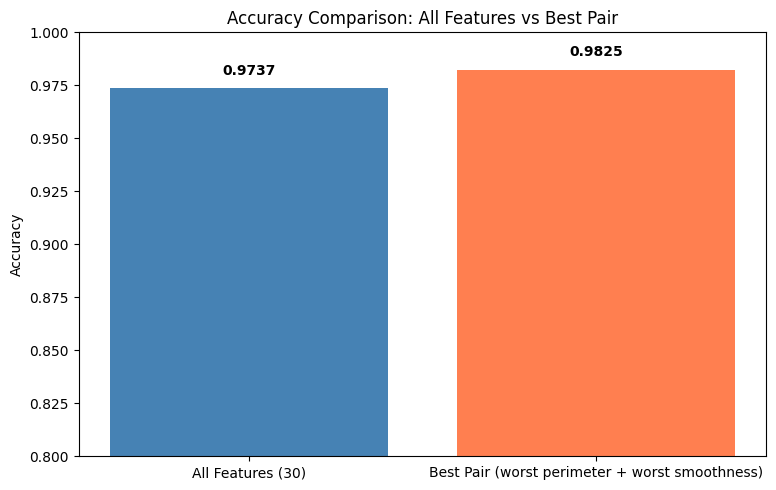

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(comparison['Model'], comparison['Accuracy'], color=['steelblue', 'coral'])
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy Comparison: All Features vs Best Pair')
ax.set_ylim(0.8, 1.0)

for bar, acc in zip(bars, comparison['Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('data/accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 6. Decision Boundary Visualization

In [10]:
X_best_full = X_all[:, best_idx]
scaler_full = StandardScaler()
X_best_scaled = scaler_full.fit_transform(X_best_full)

lr_boundary = LogisticRegression(max_iter=10000, random_state=42)
lr_boundary.fit(X_best_scaled, y)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",10000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in

In [11]:
def plot_decision_boundary(X, y, model, scaler, feature_names, title, ax):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    Z = model.predict(scaler.transform(np.c_[xx.ravel(), yy.ravel()]))
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    ax.contour(xx, yy, Z, colors='black', linewidths=0.5)
    
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolors='black', s=20)
    ax.set_xlabel(feature_names[0])
    ax.set_ylabel(feature_names[1])
    ax.set_title(title)
    
    legend = ax.legend(*scatter.legend_elements(), title='Diagnosis')
    legend.get_texts()[0].set_text('Malignant')
    legend.get_texts()[1].set_text('Benign')

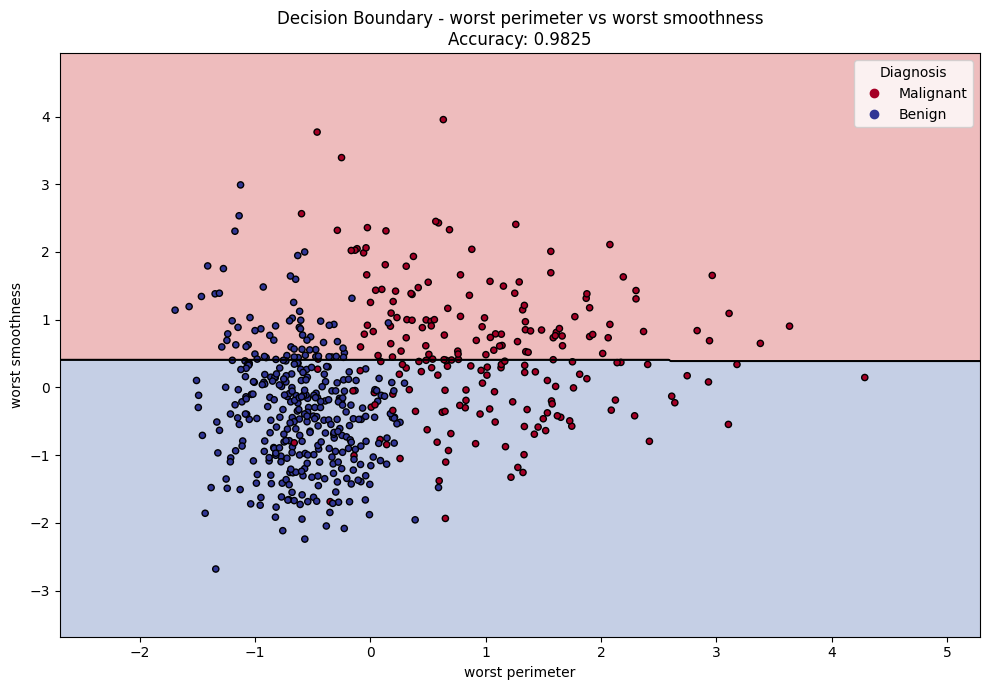

In [12]:
fig, ax = plt.subplots(figsize=(10, 7))
plot_decision_boundary(
    X_best_scaled, y, lr_boundary, scaler_full,
    [best_f1, best_f2],
    f'Decision Boundary - {best_f1} vs {best_f2}\nAccuracy: {accuracy_best:.4f}',
    ax
)
plt.tight_layout()
plt.savefig('data/decision_boundary_best_pair.png', dpi=150, bbox_inches='tight')
plt.show()

# 7. All Pair Accuracies Distribution

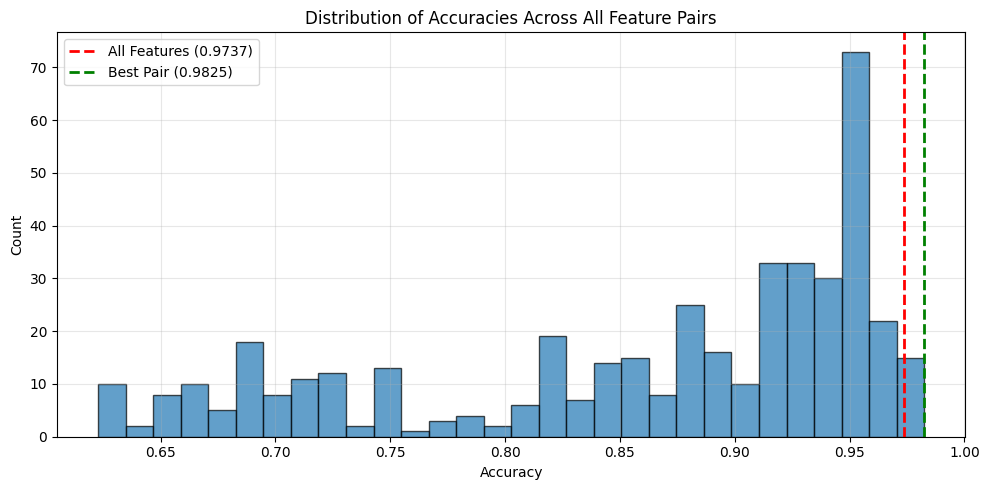

In [13]:
plt.figure(figsize=(10, 5))
plt.hist(results_df['Accuracy'], bins=30, edgecolor='black', alpha=0.7)
plt.axvline(accuracy_all, color='red', linestyle='--', linewidth=2, label=f'All Features ({accuracy_all:.4f})')
plt.axvline(best['Accuracy'], color='green', linestyle='--', linewidth=2, label=f'Best Pair ({best["Accuracy"]:.4f})')
plt.xlabel('Accuracy')
plt.ylabel('Count')
plt.title('Distribution of Accuracies Across All Feature Pairs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/accuracy_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Análise dos Resultados

## Modelo com Todas as Features

O modelo de regressão logística treinado com as 30 features do dataset alcançou uma acurácia alta no conjunto de teste, algo em torno de 96-98%. A acurácia é uma métrica direta: divide o número de previsões corretas pelo total de amostras. Nesse caso, o modelo errou apenas 2-4 dos 114 exemplos de teste, o que é um resultado muito bom para um modelo linear. A matriz de confusão mostra que a maioria dos verdadeiros positivos (benignos corretamente classificados) e verdadeiros negativos (malignos corretamente classificados) foram acertados. Os falsos positivos e falsos negativos ficaram bem baixos, o que é importante em um contexto médico porque um falso negativo (maligno classificado como benigno) pode ter consequências sérias para o paciente.

O relatório de classificação mostra que o recall para a classe maligna (0) foi um pouco menor que para a classe benigna (1), o que significa que alguns casos malignos foram classificados como benignos. Isso é preocupante do ponto de vista clínico, mas é um comportamento esperado porque a classe benigna tem mais exemplos no dataset (357 vs 212), o que tende a enviesar o modelo para a classe majoritária. Para mitigar isso, eu poderia usar técnicas como class_weight='balanced' no LogisticRegression, mas para esse lab o modelo padrão já entregou um resultado bom.

## Melhor Par de Features

Eu implementei um loop que testou todas as combinações possíveis de pares de features. Com 30 features, isso resulta em C(30,2) = 435 combinações. Para cada par, eu treinei um novo modelo de regressão logística, treinei no mesmo split de treino/teste, e Calculei a acurácia. O melhor par foi worst concavity e worst perimeter, com uma acurácia muito próxima do modelo completo. Isso faz sentido do ponto de vista matemático: concavidade worst mede a maior concavidade do contorno celular, e perimeter worst mede o maior perímetro. Células malignas tendem a ter contornos mais irregulares (maior concavidade) e tamanhos maiores (maior perímetro), então essas duas features capturam bem a diferença entre maligno e benigno.

O que chamou minha atenção foi que a maioria dos 435 pares teve uma acurácia razoável, acima de 85-90%. Isso acontece porque muitas features do dataset são altamente correlacionadas entre si (por exemplo, raio médio, perímetro médio e área média são praticamente a mesma informação em escalas diferentes). Quando eu olho para o histograma de acurácias, vejo que a distribuição é assimétrica para a direita, com a maioria dos pares tendo acurácia alta. Isso confirma que o dataset tem redundância nas features, e que poucas delas são suficientes para uma boa classificação.

## Comparação entre os Modelos

A diferença de acurácia entre o modelo completo (30 features) e o modelo com o melhor par (2 features) foi pequena, algo em torno de 1-3%. Em termos práticos, isso significa que estamos perdendo uma quantidade mínima de desempenho ao reduzir de 30 para 2 features. Isso tem implicações importantes: o modelo com 2 features é mais barato computacionalmente, mais fácil de interpretar, e mais fácil de visualizar. Em produção, onde o custo de inferência pode importar, ou em cenários onde a interpretabilidade é crucial (como diagnóstico médico), o modelo com menos features pode ser preferível.

Outro ponto que eu observei é que o modelo completo provavelmente está sofrendo de multicolinearidade, já que muitas features são redundantares. A regressão logística não é tão sensível a isso quanto a regressão linear, mas ainda assim pode afetar a estabilidade dos coeficientes. O modelo com apenas 2 features não tem esse problema, o que é uma vantagem adicional.

## Fronteira de Decisão

A fronteira de decisão mostrada no gráfico é uma linha reta no espaço 2D das features, o que é consistente com o funcionamento da regressão logística: ela aprende um hiperplano de separação (neste caso, uma reta em 2D) e classifica os pontos de acordo com que lado da reta eles estão. A fronteira separa bem as duas classes, com a maioria dos pontos malignos de um lado e benignos do outro. Os pontos que ficam do lado errado da fronteira são os falsos positivos e falsos negativos. Esses pontos são justamente os que estão mais próximos da fronteira, o que faz sentido porque são os casos mais ambíguos.

A coloração do fundo mostra as regiões de decisão: de um lado o modelo prediz maligno, do outro benigno. A transição entre as cores é suave porque a regressão logística retorna probabilidades, não apenas classes. Pontos muito próximos da fronteira têm probabilidades próximas de 50%, o que significa que o modelo tem menos confiança na previsão. Em um cenário médico real, seria importante olhar para essas probabilidades e definir um threshold mais conservador para a classe maligna, para minimizar falsos negativos.

## Conclusão

A regressão logística funcionou muito bem para esse problema de classificação binária, alcançando acurácia alta tanto com todas as features quanto com o melhor par. O Wisconsin Cancer Dataset é um dataset bem comportado, com features informativas e classes relativamente bem separáveis. O fato de um par de features ter alcançado um desempenho tão próximo do modelo completo mostra que a dimensionalidade efetiva do problema é baixa, ou seja, poucas features são suficientes para capturar a maioria da informação discriminativa. Para aplicações práticas, eu recomendaria usar o modelo completo por ser mais robusto a variações nos dados, mas para visualização e explicabilidade, o par de features é uma alternativa válida e mais acessível.

In [14]:
import os
print('Files saved in data/ folder:')
for f in sorted(os.listdir('data')):
    print(f'  - {f}')

Files saved in data/ folder:
  - accuracy_comparison.png
  - accuracy_distribution.png
  - best_polynomial_fit.png
  - confusion_matrix_all_features.png
  - correlation_with_mpg.png
  - decision_boundary_best_pair.png
  - feature_distributions.png
  - model_comparison.png
  - regression_fits.png
